# CST 4702 Lab 10: Hierarchical Clustering and DBSCAN

## Combined Notebook

This notebook combines both required parts of the lab into one file:

- Part 1: a synthetic blob dataset created with `make_blobs`
- Part 2: the real Iris dataset

Run the notebook from top to bottom so the shared setup loads once and both clustering workflows execute in order.


## Install the libraries used in this notebook

If you are opening this notebook in a clean runtime, run the next cell once.


In [1]:
%pip install -q pandas scikit-learn scipy matplotlib


## Imports and helper functions

I put the reusable plotting and scoring helpers up front so the analysis cells stay shorter and easier to follow.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)
plt.style.use("seaborn-v0_8-whitegrid")


def plot_cluster_map(points_2d, labels, title, axis=None, x_label="Component 1", y_label="Component 2"):
    if axis is None:
        axis = plt.gca()

    unique_labels = sorted(np.unique(labels))
    palette = plt.get_cmap("tab10")
    color_index = 0

    for label in unique_labels:
        mask = labels == label
        if label == -1:
            axis.scatter(
                points_2d[mask, 0],
                points_2d[mask, 1],
                color="black",
                s=45,
                alpha=0.85,
                label="noise",
            )
        else:
            axis.scatter(
                points_2d[mask, 0],
                points_2d[mask, 1],
                color=palette(color_index % 10),
                s=45,
                alpha=0.85,
                label=f"cluster {label}",
            )
            color_index += 1

    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.legend()
    axis.grid(alpha=0.25)


def silhouette_details(features, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2 or len(unique_labels) >= len(labels):
        return np.full(len(labels), np.nan), np.nan

    sample_scores = silhouette_samples(features, labels)
    average_score = silhouette_score(features, labels)
    return sample_scores, float(average_score)


def describe_clustering(features, labels, model_name):
    sample_scores, average_score = silhouette_details(features, labels)
    row = {
        "model": model_name,
        "cluster_count": int(len(set(labels)) - (1 if -1 in labels else 0)),
        "noise_points": int(np.sum(labels == -1)),
        "silhouette_score": average_score,
    }
    return row, sample_scores


def estimate_eps_from_k_distance(sorted_distances):
    x_values = np.arange(len(sorted_distances), dtype=float)
    points = np.column_stack((x_values, sorted_distances))
    start = points[0]
    end = points[-1]
    line_vector = end - start
    line_vector = line_vector / np.linalg.norm(line_vector)

    projected_points = start + np.outer((points - start) @ line_vector, line_vector)
    distances_to_line = np.linalg.norm(points - projected_points, axis=1)
    elbow_index = int(np.argmax(distances_to_line))
    return float(sorted_distances[elbow_index]), elbow_index


## Part 1: Synthetic Blob Dataset

This section creates the synthetic data, visualizes it, applies all four hierarchical clustering methods, tunes DBSCAN, and calculates silhouette values.


## Create a synthetic dataset with four blobs

The lab asks for three or more blobs, so I built four clusters with slightly different spreads.  
I also fixed the random seed so the notebook stays reproducible when I rerun it.


In [3]:
from sklearn.datasets import make_blobs

X_syn, y_syn = make_blobs(
    n_samples=[120, 110, 130, 90],
    centers=[(-7, -2), (-1, 4.5), (4.5, -4), (7, 4)],
    cluster_std=[1.0, 0.8, 1.1, 0.7],
    random_state=42,
)

syn_df = pd.DataFrame(X_syn, columns=["feature_1", "feature_2"])
print("Synthetic dataset shape:", X_syn.shape)
display(syn_df.head())


Synthetic dataset shape: (450, 2)


,feature_1,feature_2
0,6.5626,4.0183
1,-6.4850,-1.4862
2,4.6093,-3.1735
3,6.5710,3.7286
4,7.4954,3.6063


## Visualize the dataset before clustering

I am plotting the points without cluster labels first so I can judge the structure with fresh eyes.


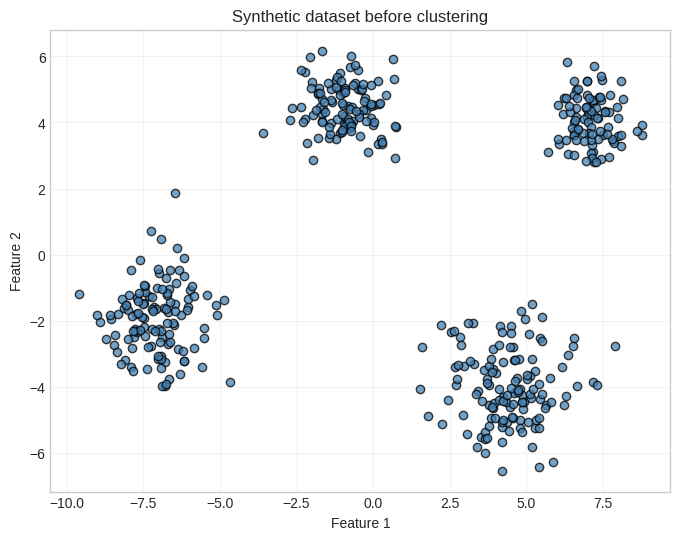

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X_syn[:, 0], X_syn[:, 1], color="steelblue", edgecolor="black", alpha=0.75)
plt.title("Synthetic dataset before clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.25)
plt.show()


## Dendrograms

I plotted all four linkage strategies so I could compare how the tree changes across methods.  
The biggest high-level splits still point to **four** natural groups, so I will use `n_clusters = 4` for the hierarchical models.


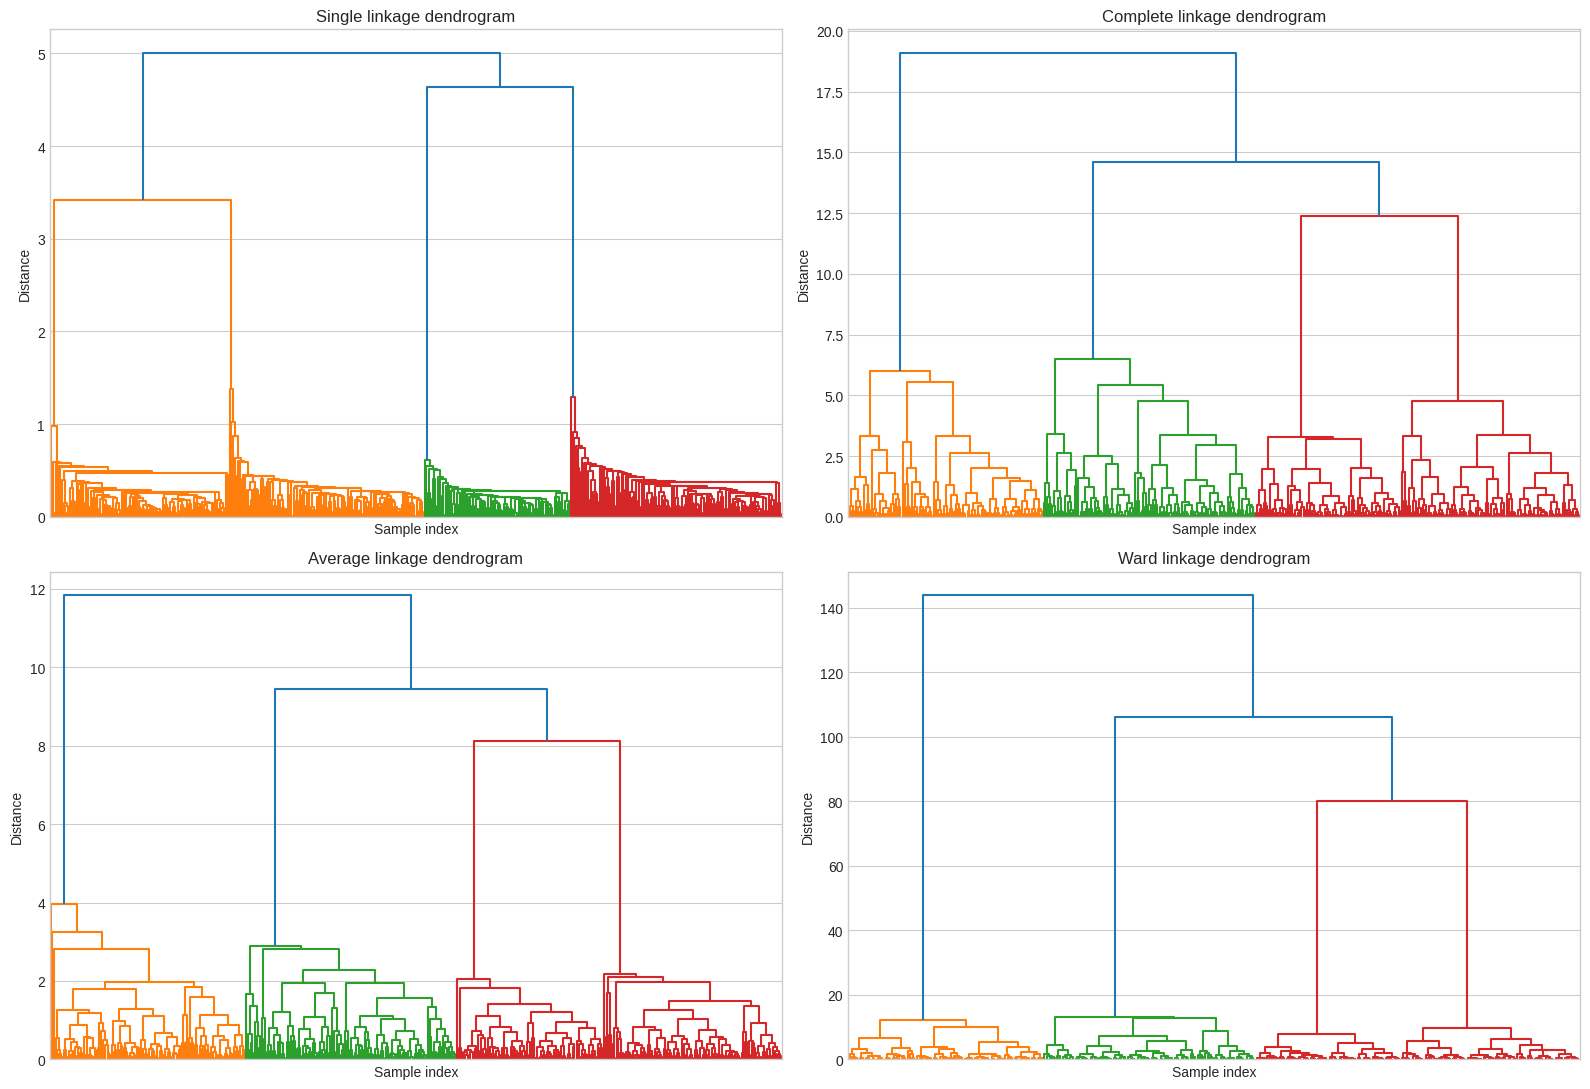

In [5]:
linkage_methods = ["single", "complete", "average", "ward"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for axis, method in zip(axes.ravel(), linkage_methods):
    linkage_matrix = linkage(X_syn, method=method)
    dendrogram(linkage_matrix, ax=axis, no_labels=True, color_threshold=None)
    axis.set_title(f"{method.title()} linkage dendrogram")
    axis.set_xlabel("Sample index")
    axis.set_ylabel("Distance")

plt.tight_layout()
plt.show()


## Hierarchical clustering results

This section runs single-link, complete-link, average-link, and Ward's method on the same synthetic data.  
I compare them visually and with silhouette score so the conclusion is not based on the scatter plot alone.


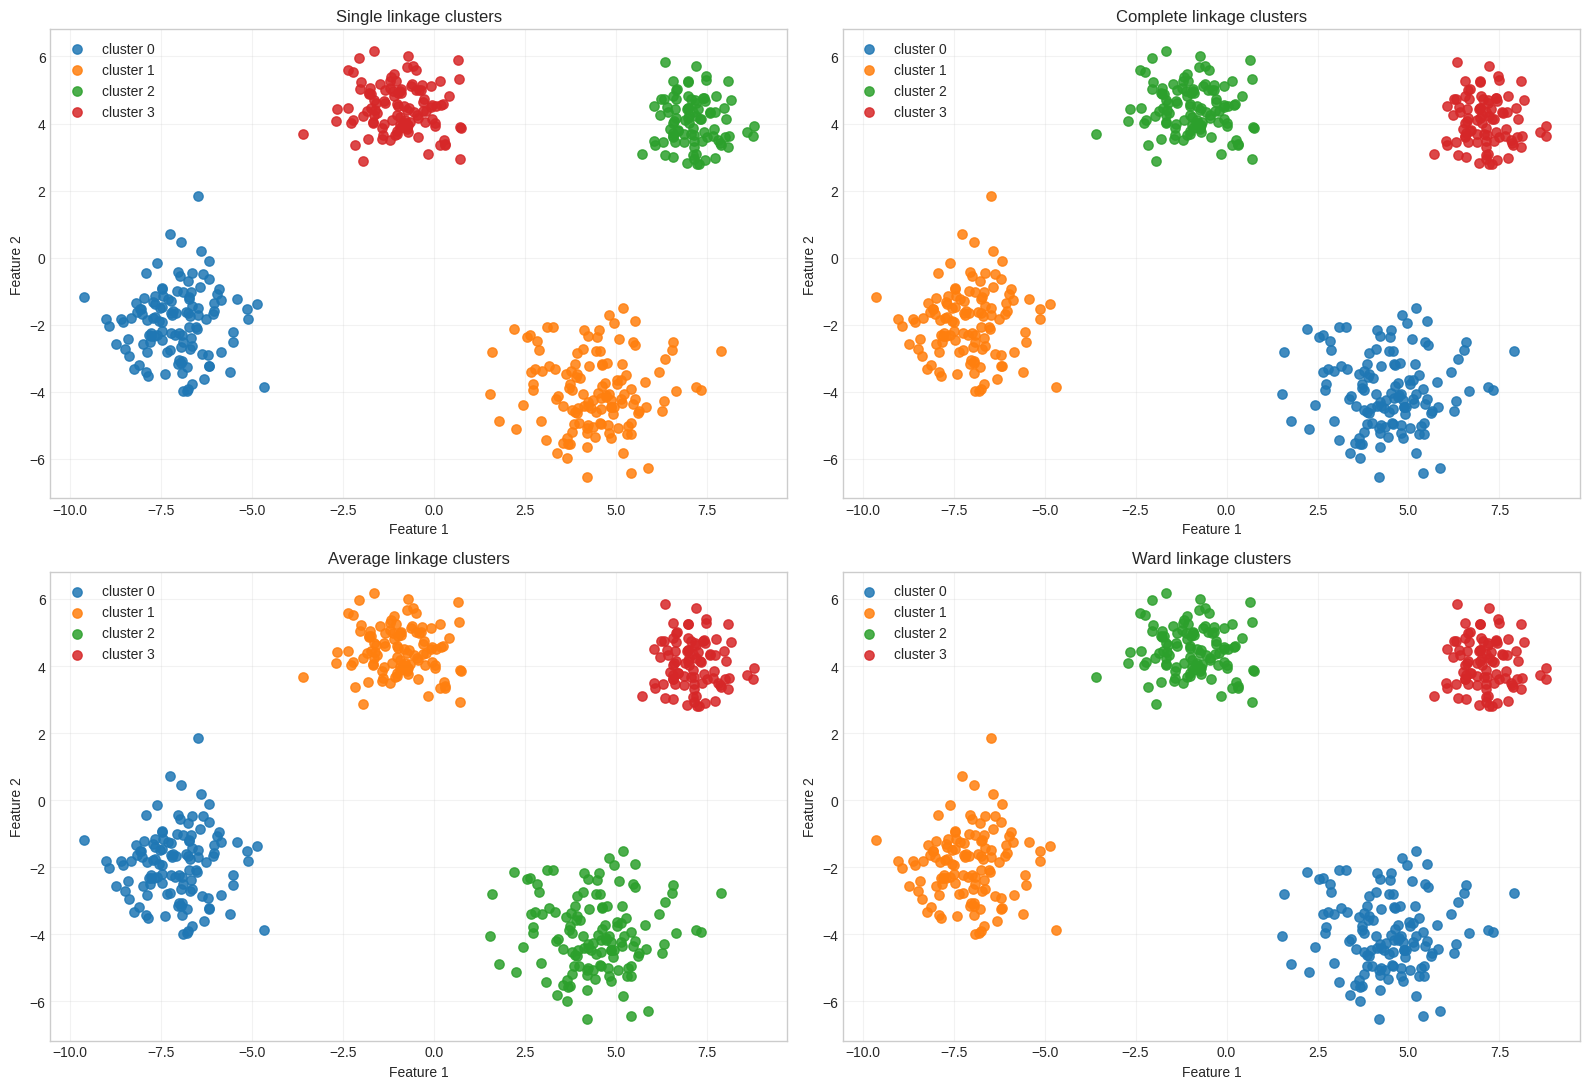

,model,cluster_count,noise_points,silhouette_score
0,Hierarchical - single,4,0,0.8057
1,Hierarchical - complete,4,0,0.8057
2,Hierarchical - average,4,0,0.8057
3,Hierarchical - ward,4,0,0.8057


In [6]:
hierarchical_rows = []
hierarchical_sample_scores = {}
hierarchical_labels = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for axis, method in zip(axes.ravel(), linkage_methods):
    model = AgglomerativeClustering(n_clusters=4, linkage=method)
    labels = model.fit_predict(X_syn)

    hierarchical_labels[method] = labels
    plot_cluster_map(
        X_syn,
        labels,
        title=f"{method.title()} linkage clusters",
        axis=axis,
        x_label="Feature 1",
        y_label="Feature 2",
    )

    row, sample_scores = describe_clustering(
        X_syn,
        labels,
        model_name=f"Hierarchical - {method}",
    )
    hierarchical_rows.append(row)
    hierarchical_sample_scores[f"{method}_sample_silhouette"] = sample_scores

plt.tight_layout()
plt.show()

hierarchical_results = pd.DataFrame(hierarchical_rows).sort_values(
    by="silhouette_score",
    ascending=False,
)
display(hierarchical_results)


## Silhouette values for every sample in the hierarchical runs

The assignment asks for per-sample silhouette values, so I kept them in a table instead of only reporting the averages.


In [7]:
hierarchical_silhouette_df = pd.DataFrame(hierarchical_sample_scores)
display(hierarchical_silhouette_df.head(10))
display(hierarchical_silhouette_df.describe().T[["mean", "min", "max"]])


,single_sample_silhouette,complete_sample_silhouette,average_sample_silhouette,ward_sample_silhouette
0,0.8697,0.8697,0.8697,0.8697
1,0.8281,0.8281,0.8281,0.8281
2,0.7870,0.7870,0.7870,0.7870
3,0.8651,0.8651,0.8651,0.8651
4,0.8772,0.8772,0.8772,0.8772
5,0.8750,0.8750,0.8750,0.8750
6,0.8497,0.8497,0.8497,0.8497
7,0.5098,0.5098,0.5098,0.5098
8,0.8696,0.8696,0.8696,0.8696
9,0.8265,0.8265,0.8265,0.8265


,mean,min,max
single_sample_silhouette,0.8057,0.3589,0.8936
complete_sample_silhouette,0.8057,0.3589,0.8936
average_sample_silhouette,0.8057,0.3589,0.8936
ward_sample_silhouette,0.8057,0.3589,0.8936


## DBSCAN parameter search

For DBSCAN, I start with the rule-of-thumb `min_samples = D + 1`.  
Here the synthetic data has `D = 2`, so I use `min_samples = 3`.

I use the K-distance graph to get a good starting point for `eps`, then I test a small range around that elbow and keep the strongest valid result.


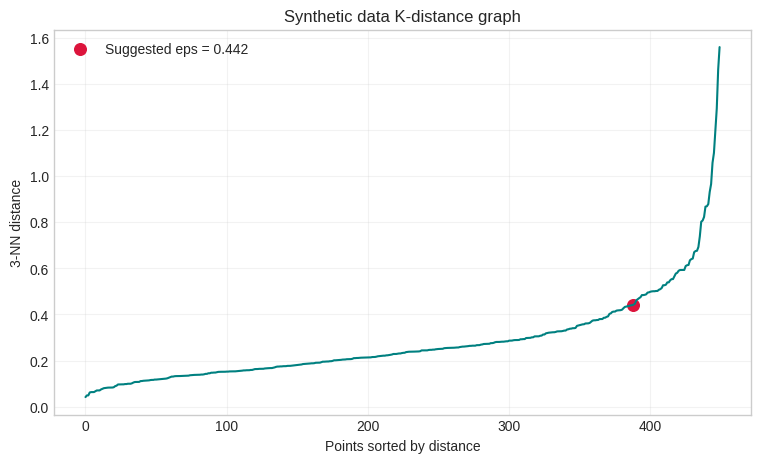

,model,cluster_count,noise_points,silhouette_score,eps
0,DBSCAN eps=0.243,33,169,-0.1590,0.243
1,DBSCAN eps=0.288,23,115,-0.0665,0.288
2,DBSCAN eps=0.332,19,84,0.0580,0.332
3,DBSCAN eps=0.376,15,68,0.0470,0.376
4,DBSCAN eps=0.42,12,47,0.1224,0.420
5,DBSCAN eps=0.464,11,37,0.3147,0.464
6,DBSCAN eps=0.509,6,31,0.5075,0.509
7,DBSCAN eps=0.553,4,24,0.7287,0.553
8,DBSCAN eps=0.597,4,16,0.7491,0.597
9,DBSCAN eps=0.641,4,10,0.7601,0.641


In [8]:
min_samples_syn = X_syn.shape[1] + 1

nn_model_syn = NearestNeighbors(n_neighbors=min_samples_syn)
distances_syn, _ = nn_model_syn.fit(X_syn).kneighbors(X_syn)
k_distances_syn = np.sort(distances_syn[:, -1])

suggested_eps_syn, elbow_index_syn = estimate_eps_from_k_distance(k_distances_syn)

plt.figure(figsize=(9, 5))
plt.plot(k_distances_syn, color="teal")
plt.scatter(
    elbow_index_syn,
    k_distances_syn[elbow_index_syn],
    color="crimson",
    s=70,
    label=f"Suggested eps = {suggested_eps_syn:.3f}",
)
plt.title("Synthetic data K-distance graph")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples_syn}-NN distance")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

eps_candidates_syn = np.unique(
    np.round(
        np.linspace(
            max(0.05, suggested_eps_syn * 0.55),
            suggested_eps_syn * 1.45,
            10,
        ),
        3,
    )
)

search_rows_syn = []
for eps in eps_candidates_syn:
    labels = DBSCAN(eps=float(eps), min_samples=min_samples_syn).fit_predict(X_syn)
    row, _ = describe_clustering(X_syn, labels, model_name=f"DBSCAN eps={eps}")
    row["eps"] = float(eps)
    search_rows_syn.append(row)

dbscan_search_syn = pd.DataFrame(search_rows_syn)
display(dbscan_search_syn.sort_values(by="eps"))


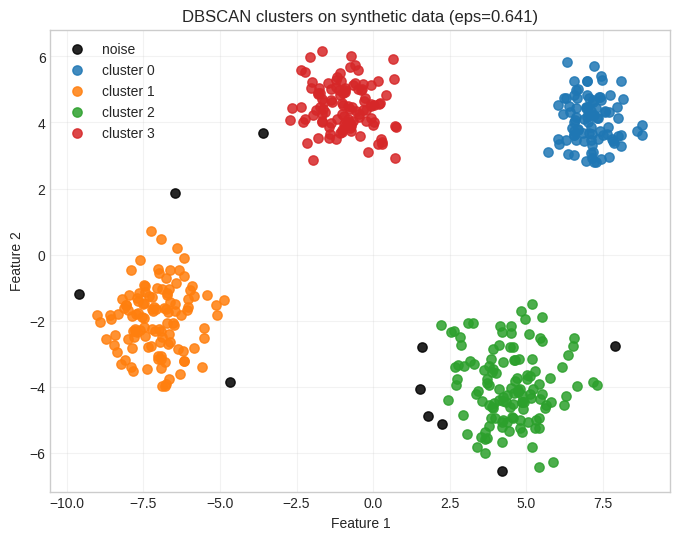

Chosen eps: 0.641
Total noise points found: 10


,model,cluster_count,noise_points,silhouette_score
0,"DBSCAN (eps=0.641, min_samples=3)",4,10,0.7601


,cluster_label,sample_silhouette
0,0,0.8693
1,1,0.8225
2,2,0.7628
3,0,0.8646
4,0,0.8765
5,0,0.8746
6,0,0.8488
7,2,0.5214
8,3,0.8715
9,0,0.8260


,sample_silhouette
count,450.0000
mean,0.7601
std,0.2160
min,-0.7395
25%,0.7483
50%,0.8038
75%,0.8494
max,0.8933


In [9]:
valid_dbscan_syn = dbscan_search_syn.dropna(subset=["silhouette_score"]).copy()
valid_dbscan_syn = valid_dbscan_syn[valid_dbscan_syn["cluster_count"] >= 2].copy()

best_dbscan_syn = valid_dbscan_syn.sort_values(
    by=["silhouette_score", "noise_points"],
    ascending=[False, True],
).iloc[0]

best_eps_syn = float(best_dbscan_syn["eps"])
dbscan_syn = DBSCAN(eps=best_eps_syn, min_samples=min_samples_syn)
dbscan_syn_labels = dbscan_syn.fit_predict(X_syn)

dbscan_syn_row, dbscan_syn_sample_scores = describe_clustering(
    X_syn,
    dbscan_syn_labels,
    model_name=f"DBSCAN (eps={best_eps_syn:.3f}, min_samples={min_samples_syn})",
)

plt.figure(figsize=(8, 6))
plot_cluster_map(
    X_syn,
    dbscan_syn_labels,
    title=f"DBSCAN clusters on synthetic data (eps={best_eps_syn:.3f})",
    x_label="Feature 1",
    y_label="Feature 2",
)
plt.show()

print("Chosen eps:", round(best_eps_syn, 3))
print("Total noise points found:", dbscan_syn_row["noise_points"])

dbscan_syn_silhouette_df = pd.DataFrame(
    {
        "cluster_label": dbscan_syn_labels,
        "sample_silhouette": dbscan_syn_sample_scores,
    }
)

display(pd.DataFrame([dbscan_syn_row]))
display(dbscan_syn_silhouette_df.head(10))
display(dbscan_syn_silhouette_df["sample_silhouette"].describe())


## Final comparison

This makes it easier to compare the average silhouette score from the hierarchical models against the best DBSCAN run on the same dataset.


In [10]:
synthetic_comparison = pd.concat(
    [
        hierarchical_results,
        pd.DataFrame([dbscan_syn_row]),
    ],
    ignore_index=True,
).sort_values(by="silhouette_score", ascending=False)

display(synthetic_comparison)


,model,cluster_count,noise_points,silhouette_score
0,Hierarchical - single,4,0,0.8057
1,Hierarchical - complete,4,0,0.8057
2,Hierarchical - average,4,0,0.8057
3,Hierarchical - ward,4,0,0.8057
4,"DBSCAN (eps=0.641, min_samples=3)",4,10,0.7601


## Short discussion: why DBSCAN can look good but still score lower

DBSCAN can produce clusters that look very natural to a person because it handles shapes that are uneven, stretched out, or separated by low-density gaps.  
Silhouette score is less flexible because it favors clusters that are compact and clearly separated in a more convex way.  
On top of that, DBSCAN labels some border points as noise, and those edge cases can pull the average silhouette down even when the visual clustering still makes sense.


---

## Part 2: Iris Dataset

This section reuses the same helper functions on the real dataset so both parts of the lab stay in one notebook.


## Load the Iris dataset

I picked Iris for the real dataset because it is standard, small enough to inspect carefully, and still has more than two features.  
Per the lab instructions, I scale the original features for clustering and use PCA only to compress the data to two dimensions for plotting.


In [11]:
from sklearn.datasets import load_iris

iris_bundle = load_iris(as_frame=True)
iris_features = iris_bundle.data.copy()
iris_target = iris_bundle.target.copy()
iris_names = iris_bundle.target_names

scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(iris_features)

pca = PCA(n_components=2)
X_iris_pca = pca.fit_transform(X_iris_scaled)

print("Original Iris feature shape:", iris_features.shape)
print("Scaled feature shape:", X_iris_scaled.shape)
display(iris_features.head())


Original Iris feature shape: (150, 4)
Scaled feature shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Visualize the dataset with PCA

I only use PCA here for plotting. The clustering models themselves will still train on the original **scaled 4D data**.


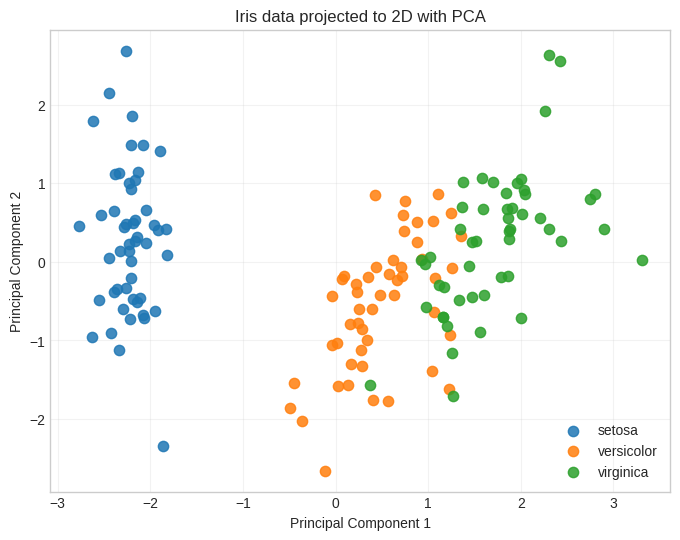

In [12]:
plt.figure(figsize=(8, 6))

for class_id, class_name in enumerate(iris_names):
    mask = iris_target.to_numpy() == class_id
    plt.scatter(
        X_iris_pca[mask, 0],
        X_iris_pca[mask, 1],
        s=55,
        alpha=0.85,
        label=class_name,
    )

plt.title("Iris data projected to 2D with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## Dendrograms on the scaled original features

The dendrograms are built from the scaled 4D feature space, not from the PCA view.  
The large branch split suggests that using **three clusters** is a reasonable choice here.


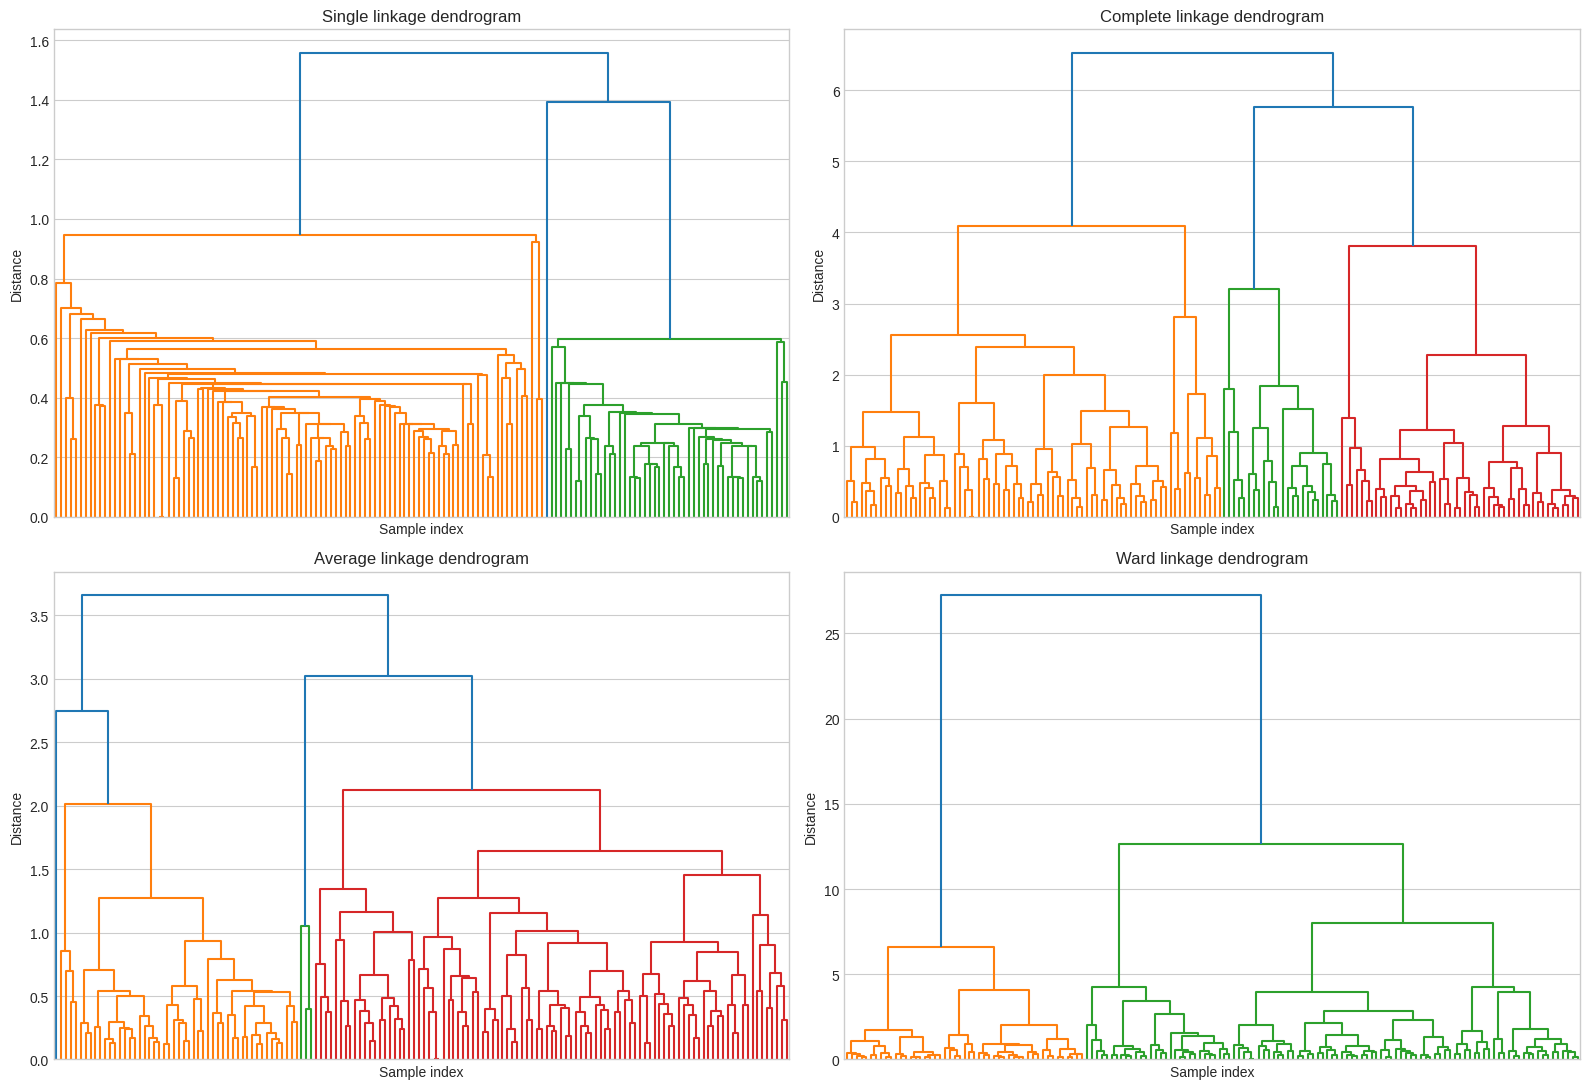

In [13]:
linkage_methods = ["single", "complete", "average", "ward"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for axis, method in zip(axes.ravel(), linkage_methods):
    linkage_matrix = linkage(X_iris_scaled, method=method)
    dendrogram(linkage_matrix, ax=axis, no_labels=True, color_threshold=None)
    axis.set_title(f"{method.title()} linkage dendrogram")
    axis.set_xlabel("Sample index")
    axis.set_ylabel("Distance")

plt.tight_layout()
plt.show()


## Hierarchical clustering results

Every model below is trained on the scaled 4D data, and the scatter plots are shown in PCA space just to make the cluster boundaries visible.


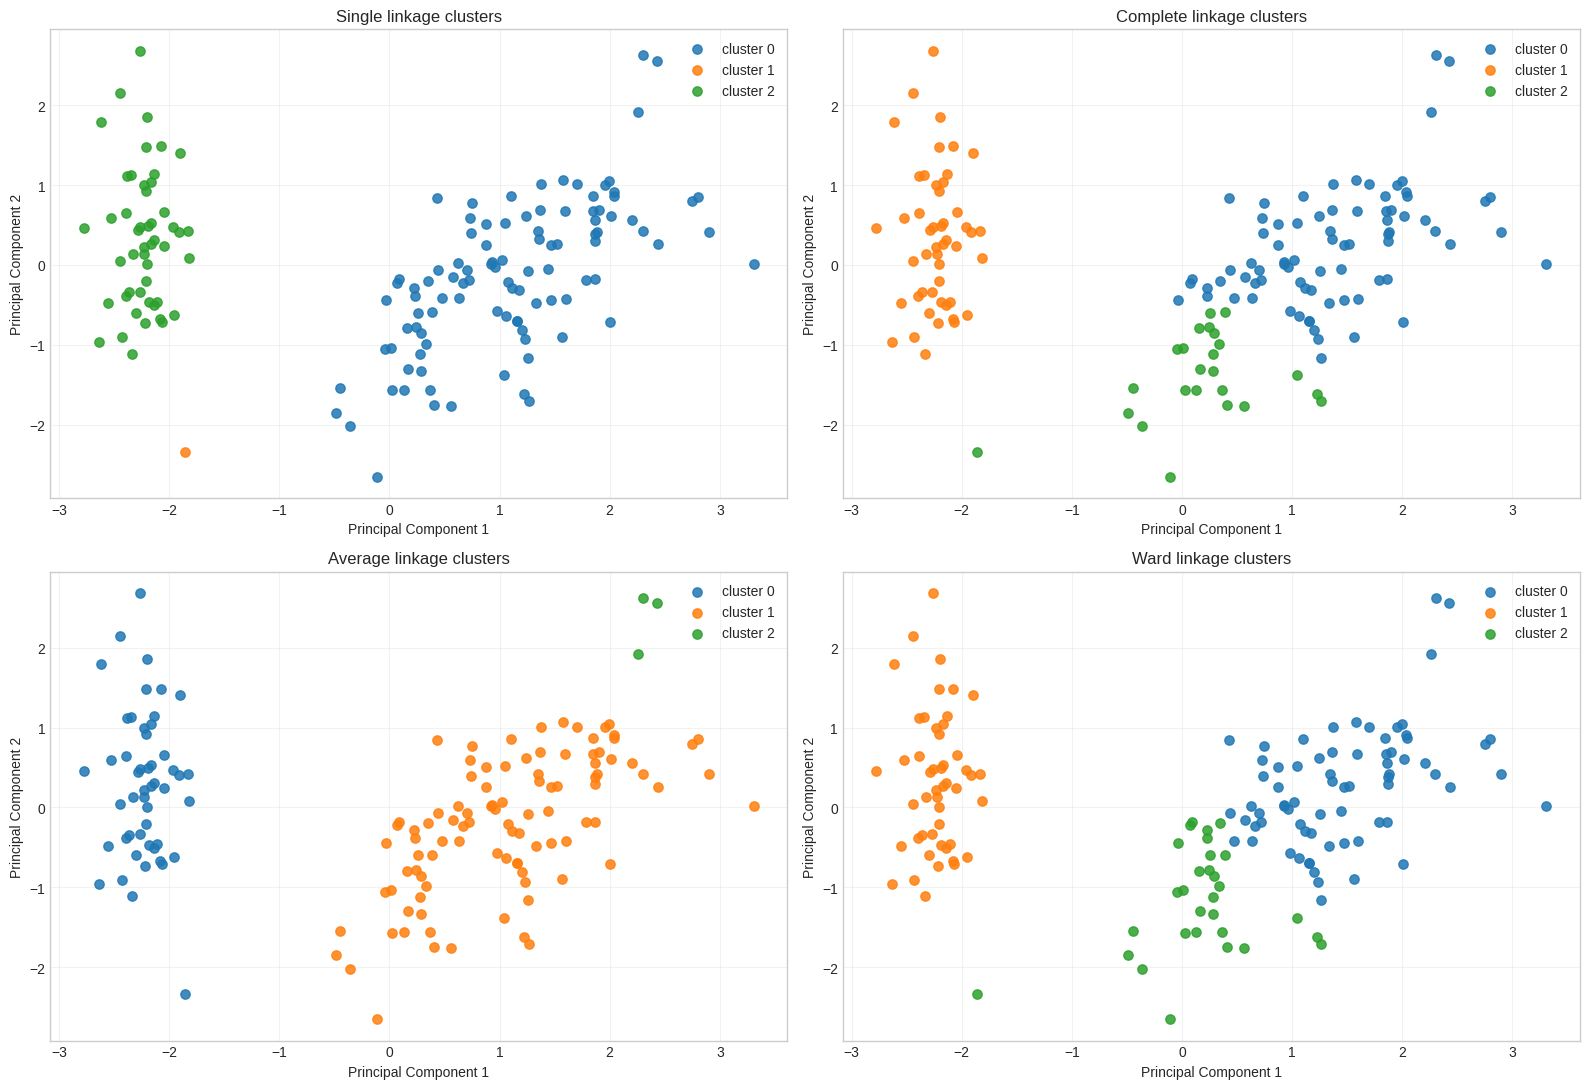

,model,cluster_count,noise_points,silhouette_score
0,Hierarchical - single,3,0,0.5046
2,Hierarchical - average,3,0,0.4803
1,Hierarchical - complete,3,0,0.4496
3,Hierarchical - ward,3,0,0.4467


In [14]:
hierarchical_rows_iris = []
hierarchical_sample_scores_iris = {}
hierarchical_labels_iris = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for axis, method in zip(axes.ravel(), linkage_methods):
    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = model.fit_predict(X_iris_scaled)

    hierarchical_labels_iris[method] = labels
    plot_cluster_map(
        X_iris_pca,
        labels,
        title=f"{method.title()} linkage clusters",
        axis=axis,
        x_label="Principal Component 1",
        y_label="Principal Component 2",
    )

    row, sample_scores = describe_clustering(
        X_iris_scaled,
        labels,
        model_name=f"Hierarchical - {method}",
    )
    hierarchical_rows_iris.append(row)
    hierarchical_sample_scores_iris[f"{method}_sample_silhouette"] = sample_scores

plt.tight_layout()
plt.show()

hierarchical_results_iris = pd.DataFrame(hierarchical_rows_iris).sort_values(
    by="silhouette_score",
    ascending=False,
)
display(hierarchical_results_iris)


## Silhouette values for every sample in the hierarchical runs


In [15]:
hierarchical_silhouette_df_iris = pd.DataFrame(hierarchical_sample_scores_iris)
display(hierarchical_silhouette_df_iris.head(10))
display(hierarchical_silhouette_df_iris.describe().T[["mean", "min", "max"]])


,single_sample_silhouette,complete_sample_silhouette,average_sample_silhouette,ward_sample_silhouette
0,0.7153,0.7438,0.7605,0.7340
1,0.2934,0.5225,0.6395,0.5171
2,0.5363,0.6607,0.7227,0.6533
3,0.3973,0.5882,0.6789,0.5815
4,0.7131,0.7400,0.7527,0.7299
5,0.6424,0.6396,0.6266,0.6222
6,0.6267,0.6960,0.7343,0.6863
7,0.6949,0.7352,0.7617,0.7258
8,-0.1006,0.4117,0.5747,0.4121
9,0.4539,0.6044,0.6874,0.5974


,mean,min,max
single_sample_silhouette,0.5046,-0.3825,0.7153
complete_sample_silhouette,0.4496,-0.2989,0.7438
average_sample_silhouette,0.4803,-0.2350,0.7945
ward_sample_silhouette,0.4467,-0.2304,0.7340


## DBSCAN parameter search

The Iris dataset has four original dimensions, so the rule of thumb gives `min_samples = 5`.  
Again, I use the K-distance plot for the first `eps` estimate and then test a small range around it.


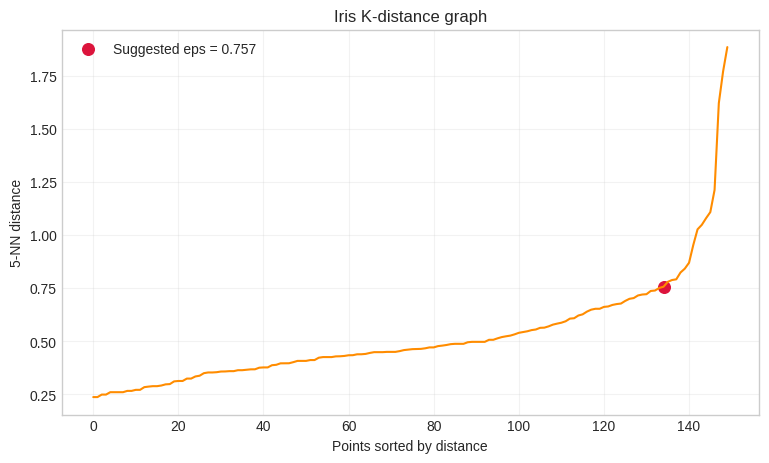

,model,cluster_count,noise_points,silhouette_score,eps
0,DBSCAN eps=0.416,5,63,0.0619,0.416
1,DBSCAN eps=0.492,2,36,0.3419,0.492
2,DBSCAN eps=0.568,2,29,0.3880,0.568
3,DBSCAN eps=0.643,2,15,0.4741,0.643
4,DBSCAN eps=0.719,2,6,0.5234,0.719
5,DBSCAN eps=0.795,2,4,0.5217,0.795
6,DBSCAN eps=0.87,2,4,0.5217,0.870
7,DBSCAN eps=0.946,2,4,0.5217,0.946
8,DBSCAN eps=1.022,2,3,0.5383,1.022
9,DBSCAN eps=1.097,2,2,0.5518,1.097


In [16]:
min_samples_iris = X_iris_scaled.shape[1] + 1

nn_model_iris = NearestNeighbors(n_neighbors=min_samples_iris)
distances_iris, _ = nn_model_iris.fit(X_iris_scaled).kneighbors(X_iris_scaled)
k_distances_iris = np.sort(distances_iris[:, -1])

suggested_eps_iris, elbow_index_iris = estimate_eps_from_k_distance(k_distances_iris)

plt.figure(figsize=(9, 5))
plt.plot(k_distances_iris, color="darkorange")
plt.scatter(
    elbow_index_iris,
    k_distances_iris[elbow_index_iris],
    color="crimson",
    s=70,
    label=f"Suggested eps = {suggested_eps_iris:.3f}",
)
plt.title("Iris K-distance graph")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples_iris}-NN distance")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

eps_candidates_iris = np.unique(
    np.round(
        np.linspace(
            max(0.10, suggested_eps_iris * 0.55),
            suggested_eps_iris * 1.45,
            10,
        ),
        3,
    )
)

search_rows_iris = []
for eps in eps_candidates_iris:
    labels = DBSCAN(eps=float(eps), min_samples=min_samples_iris).fit_predict(X_iris_scaled)
    row, _ = describe_clustering(X_iris_scaled, labels, model_name=f"DBSCAN eps={eps}")
    row["eps"] = float(eps)
    search_rows_iris.append(row)

dbscan_search_iris = pd.DataFrame(search_rows_iris)
display(dbscan_search_iris.sort_values(by="eps"))


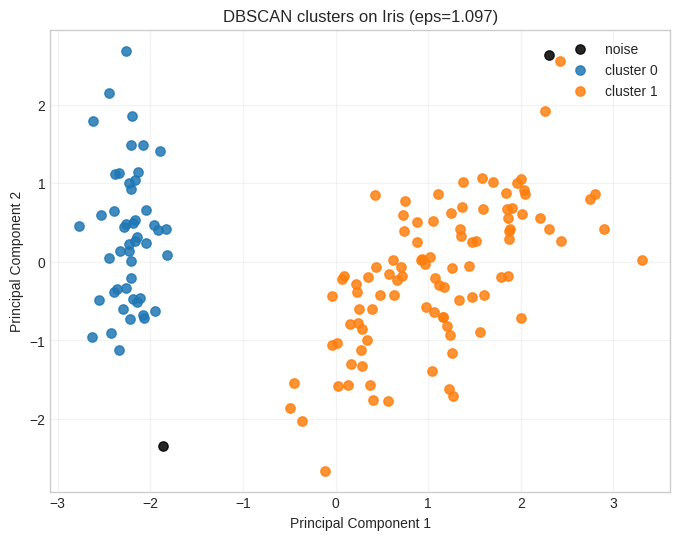

Chosen eps: 1.097
Total noise points found: 2


,model,cluster_count,noise_points,silhouette_score
0,"DBSCAN (eps=1.097, min_samples=5)",2,2,0.5518


,cluster_label,sample_silhouette
0,0,0.7740
1,0,0.6467
2,0,0.7319
3,0,0.6866
4,0,0.7663
5,0,0.6416
6,0,0.7453
7,0,0.7742
8,0,0.5788
9,0,0.6960


,sample_silhouette
count,150.0000
mean,0.5518
std,0.1868
min,-0.5773
25%,0.4845
50%,0.5786
75%,0.6497
max,0.7742


In [17]:
valid_dbscan_iris = dbscan_search_iris.dropna(subset=["silhouette_score"]).copy()
valid_dbscan_iris = valid_dbscan_iris[valid_dbscan_iris["cluster_count"] >= 2].copy()

best_dbscan_iris = valid_dbscan_iris.sort_values(
    by=["silhouette_score", "noise_points"],
    ascending=[False, True],
).iloc[0]

best_eps_iris = float(best_dbscan_iris["eps"])
dbscan_iris = DBSCAN(eps=best_eps_iris, min_samples=min_samples_iris)
dbscan_iris_labels = dbscan_iris.fit_predict(X_iris_scaled)

dbscan_iris_row, dbscan_iris_sample_scores = describe_clustering(
    X_iris_scaled,
    dbscan_iris_labels,
    model_name=f"DBSCAN (eps={best_eps_iris:.3f}, min_samples={min_samples_iris})",
)

plt.figure(figsize=(8, 6))
plot_cluster_map(
    X_iris_pca,
    dbscan_iris_labels,
    title=f"DBSCAN clusters on Iris (eps={best_eps_iris:.3f})",
    x_label="Principal Component 1",
    y_label="Principal Component 2",
)
plt.show()

print("Chosen eps:", round(best_eps_iris, 3))
print("Total noise points found:", dbscan_iris_row["noise_points"])

dbscan_iris_silhouette_df = pd.DataFrame(
    {
        "cluster_label": dbscan_iris_labels,
        "sample_silhouette": dbscan_iris_sample_scores,
    }
)

display(pd.DataFrame([dbscan_iris_row]))
display(dbscan_iris_silhouette_df.head(10))
display(dbscan_iris_silhouette_df["sample_silhouette"].describe())


## Final comparison


In [18]:
iris_comparison = pd.concat(
    [
        hierarchical_results_iris,
        pd.DataFrame([dbscan_iris_row]),
    ],
    ignore_index=True,
).sort_values(by="silhouette_score", ascending=False)

display(iris_comparison)


,model,cluster_count,noise_points,silhouette_score
4,"DBSCAN (eps=1.097, min_samples=5)",2,2,0.5518
0,Hierarchical - single,3,0,0.5046
1,Hierarchical - average,3,0,0.4803
2,Hierarchical - complete,3,0,0.4496
3,Hierarchical - ward,3,0,0.4467


## Short discussion: why DBSCAN can look right but still score lower

A visually good DBSCAN result does not always win on silhouette score because silhouette assumes clusters should be internally tight and cleanly separated from the next group.  
DBSCAN is designed for density-based structure, so it can keep curved shapes, border points, and noise that make visual sense but do not look as compact to the metric.  
In other words, the eye can reward natural shape, while silhouette tends to reward compact geometry.
